## Imports e Configuração

Situação de Aprendizagem (Projeto Avaliativo) - Módulo 1 - Semana 14

### Fase 1: Análise Exploratória (EDA)

1.1 - Análise inicial dos dados

In [1]:
# Leitura de CSV — o formato mais comum

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


df = pd.read_csv('manutencao_preditiva.csv',sep=',')


In [2]:
# Realizando inspeção inicial do arquivo

print(df.info())

# arquivo possui 10000 linhas e 14 colunas

# Verifica-se dados faltantes em: "temperatura_ar_k", "temperatura_processo_k"
# "velocidade_rotacao_rpm" e "torque_m". Para cada um faltam 500 dados.

# Temos duas colunas com informações do tipo "str", as demais são do tipo 
# int64 ou float64.

# As do tipo "str" precisam ou ser descartadas, ou transformadas em int64 
# ou float64 para poderem ser utilizadas pelo futuro modelo.

# Neste caso a informação do "id_produto" não interessa para o modelo pois 
# é uma identificação exclusiva de cada produto.

# Já a informação "tipo" é importante pois divide os equipamentos em 3 classes
# que podem ter comportamentos distintos e impactar o resultado do modelo.


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

In [3]:
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


1.2 - Gráficos

Os gráficos mostram que temos mais maquinas classificadas como Low, e menos como High.

Os histogramas mostram uma distribuição praticamente normal, menos a variável "velocidade_rotação_rpm" que possui uma assimetria positiva forte. Esta variável tem concentração de valores entre 1300 e 1600 rpm, com uma longa cauda de estendendo até 2800 rpm, que são possíveis outliers.   

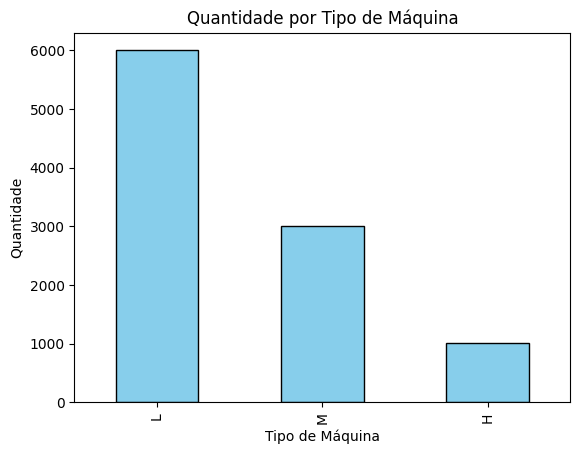

In [4]:
# Grafico de quantidade de maquinas por tipo

# temos mais maquinas classificadas como Low, e menos maquinas como High

df['tipo'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade por Tipo de Máquina')
plt.xlabel('Tipo de Máquina')
plt.ylabel('Quantidade')
plt.show()

plt.show()

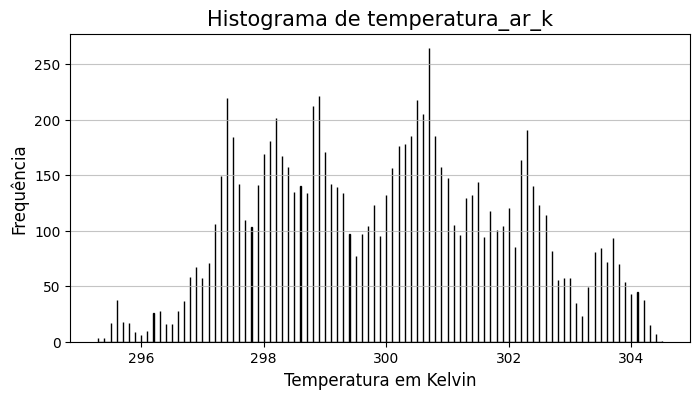

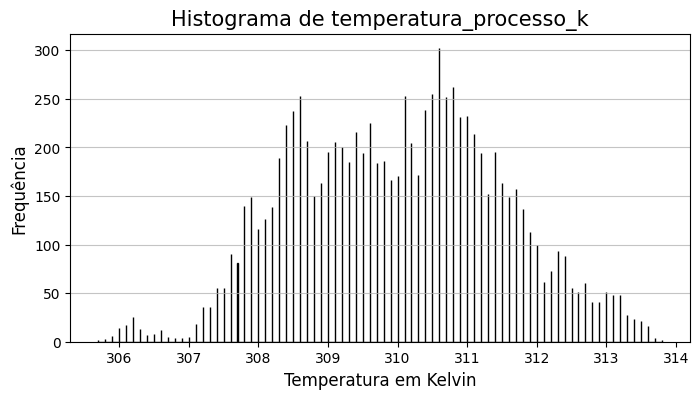

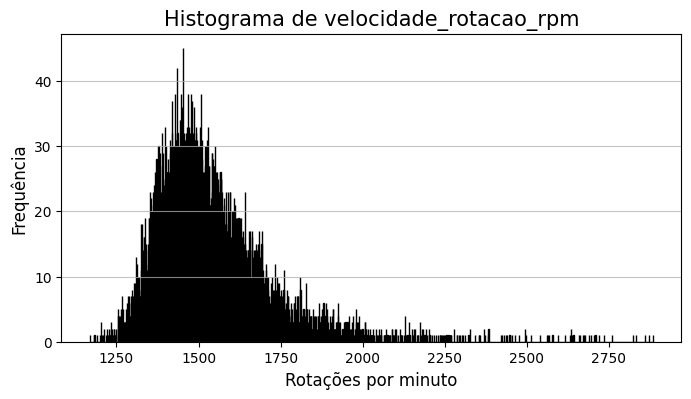

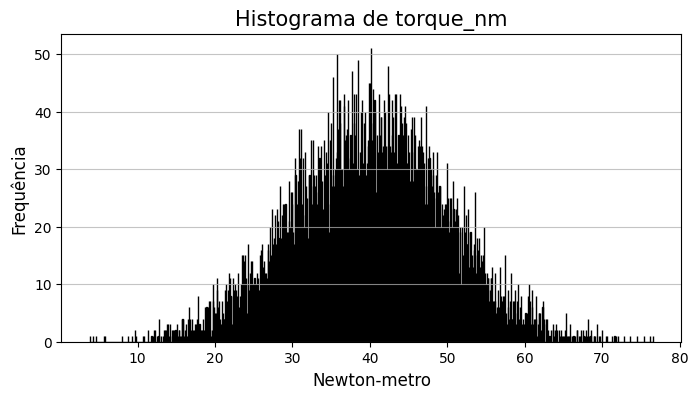

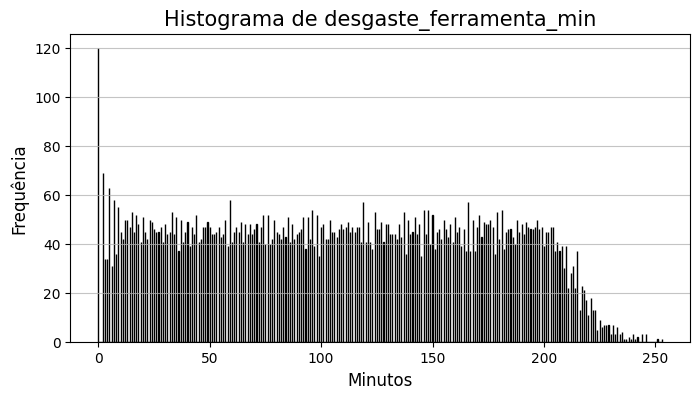

In [5]:
# Gráfico histograma de distribuição das variáveis

plt.figure(figsize=(8, 4))
plt.hist(df['temperatura_ar_k'], bins=10000, color='skyblue', edgecolor='black')
plt.title('Histograma de temperatura_ar_k', fontsize=15)
plt.xlabel('Temperatura em Kelvin', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['temperatura_processo_k'], bins=10000, color='skyblue', edgecolor='black')
plt.title('Histograma de temperatura_processo_k', fontsize=15)
plt.xlabel('Temperatura em Kelvin', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['velocidade_rotacao_rpm'], bins=10000, color='skyblue', edgecolor='black')
plt.title('Histograma de velocidade_rotacao_rpm', fontsize=15)
plt.xlabel('Rotações por minuto', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['torque_nm'], bins=10000, color='skyblue', edgecolor='black')
plt.title('Histograma de torque_nm', fontsize=15)
plt.xlabel('Newton-metro', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['desgaste_ferramenta_min'], bins=10000, color='skyblue', edgecolor='black')
plt.title('Histograma de desgaste_ferramenta_min', fontsize=15)
plt.xlabel('Minutos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.show()


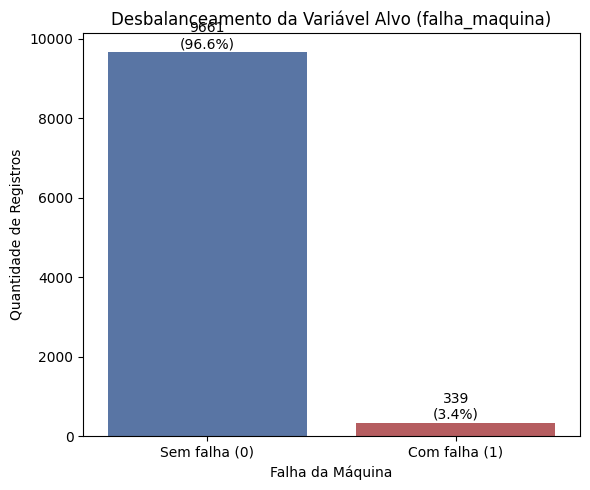

In [6]:
# Gráfico de barras do desbalanceamento da variável alvo

# Contagem de cada classe
contagem = df['falha_maquina'].value_counts()

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=contagem.index, y=contagem.values, hue=contagem.index, 
                  palette=['#4C72B0', '#C44E52'], legend=False)

plt.title('Desbalanceamento da Variável Alvo (falha_maquina)')
plt.xlabel('Falha da Máquina')
plt.ylabel('Quantidade de Registros')
plt.xticks([0, 1], ['Sem falha (0)', 'Com falha (1)'])

# Adicionar os valores em cima de cada barra
for i, valor in enumerate(contagem.values):
    percentual = (valor / contagem.sum()) * 100
    ax.text(i, valor + 100, f'{valor}\n({percentual:.1f}%)', 
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()


O gráfico mostra ser importante inclui uma etapa de balanceamento de dados. Mantendo os dados como estão, o modelo tende a "aprender" que basta prever sempre "sem falha" pra acertar 96% das vezes — o que é inútil na prática, já que o objetivo é justamente detectar as falhas.

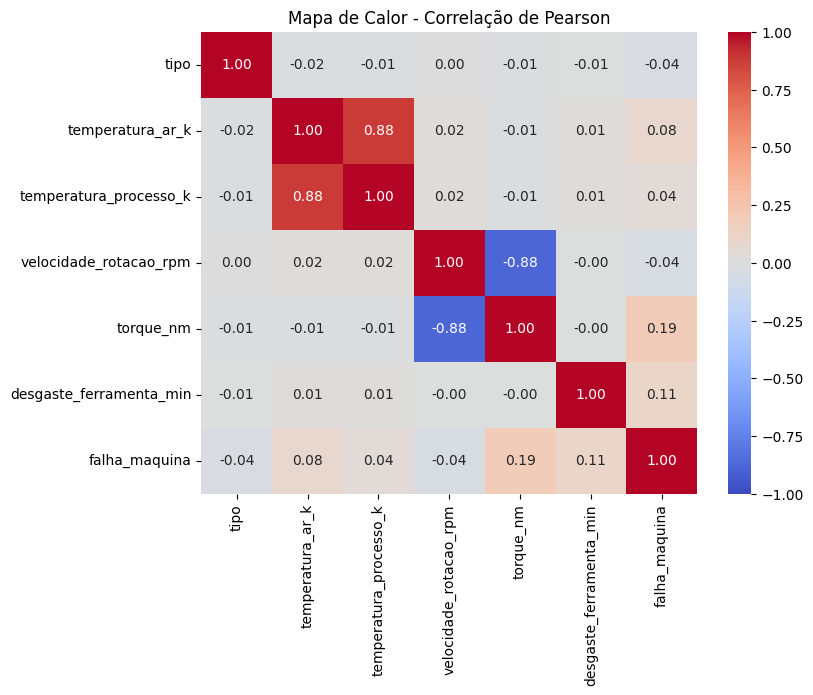

In [7]:
# Mapa de calor de correlação de Pearson

# Primeiro trasformar variável "tipo" em numeros

mapa_tipo = {'L': 0, 'M': 1, 'H': 2}
df['tipo'] = df['tipo'].map(mapa_tipo)

# Excluir as colunas de consulta - não são variáveis preditoras

df = df.drop(columns=['udi','id_produto','falha_twf','falha_hdf','falha_pwf','falha_osf','falha_rnf'])

matriz_correlacao = df.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()

O que a correlação de Pearson mede
Varia de -1 a +1:

+1 → correlação positiva perfeita (uma sobe, a outra sobe)

-1 → correlação negativa perfeita (uma sobe, a outra desce)

 0 → nenhuma relação linear

A correlação mais forte positiva 0.88 é entre "temperatura_ar_k" e "temperatura_processo_k" já que quando aumenta a temperatura do ambiente, também sobre o do processo pois depende do ar ao redor.

A correlação mais forte negativa -0.88 é entre "velocidade_rotação_rpm" e " torque_nm". Como potência = torque X velociade rotação, para manter a potência do equipamento quando a rotação cai, o torque tende a aumentar e vice-versa.

Estes dois casos podem indicar MULTICOLINEARIDADE podendo ser estas variáveis candidatas a remoção ou combinação.

As correlações das variáveis com a variável "falha_maquina" são:
* 0.19 com torque
* 0.11 com desgaste_ferramenta_min
* 0.08 com temperatura_ar_k

Nenhuma é muito forte isoladamente, indicando que a causa da falha é uma combinação de fatores. Nestes casos os modelos como KNN e Decision Tree são mais adequados por capturarem interações não-lineares entre variáveis.


### Fase 2: Limpeza e Tratamento de Dados (Data Prep)

2.1 - Identificação de linhas duplicadas

In [8]:
# Identificar linhas duplicadas (considerando todas as colunas)
duplicadas = df.duplicated()
print(f"Número de linhas duplicadas: {duplicadas.sum()}")

# Ver quais são as linhas duplicadas
df[duplicadas]

print('Não foram encontradas linhas duplicadas')

Número de linhas duplicadas: 185
Não foram encontradas linhas duplicadas


2.2 - Identificar dados ausentes

In [9]:
# Contagem de valores ausentes por coluna
print(df.isnull().sum())

print('Foram encontrados dados ausentes nestas colunas acima - 500 em cada')


tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
dtype: int64
Foram encontrados dados ausentes nestas colunas acima - 500 em cada


2.3 - Gerar **boxplots** para identificar outliers.

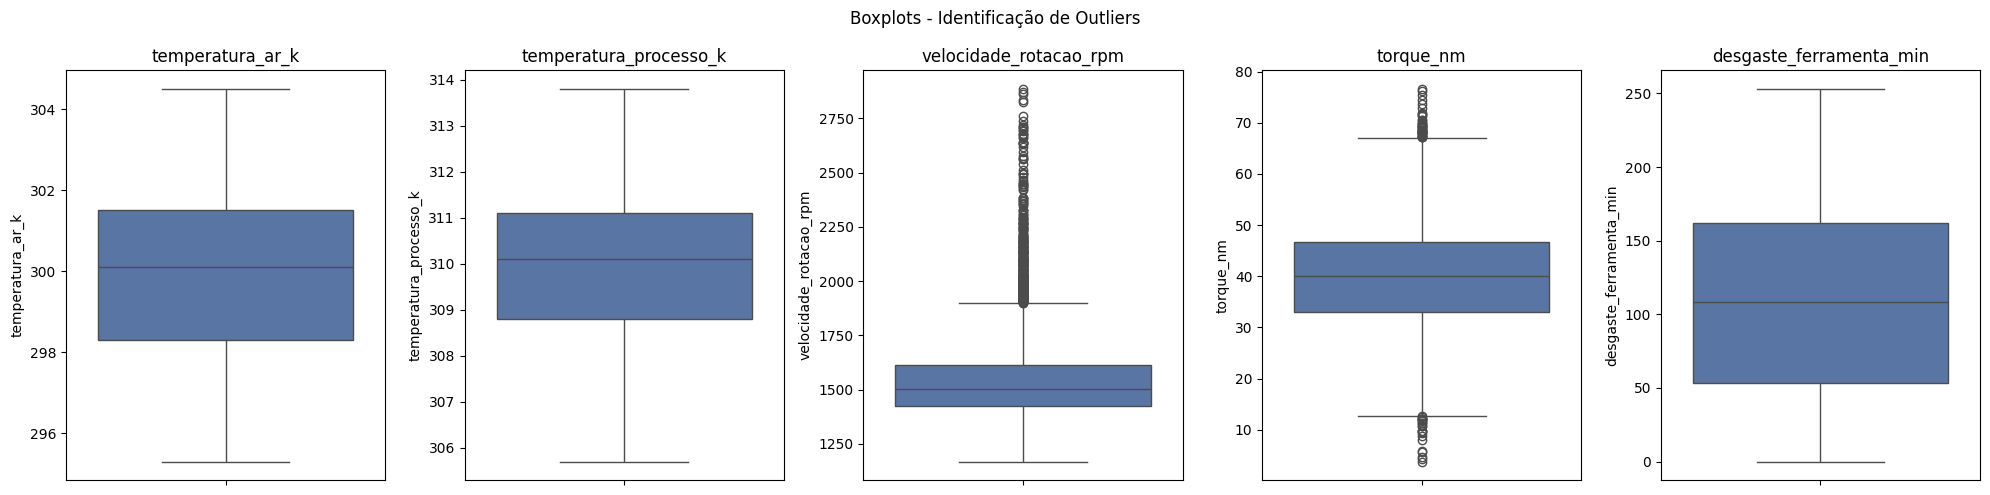

temperatura_ar_k: 0 outliers | limites: [293.50, 306.30]
temperatura_processo_k: 0 outliers | limites: [305.35, 314.55]
velocidade_rotacao_rpm: 398 outliers | limites: [1138.00, 1898.00]
torque_nm: 63 outliers | limites: [12.70, 67.10]
desgaste_ferramenta_min: 0 outliers | limites: [-110.50, 325.50]


In [10]:
verifica_outlier = ['temperatura_ar_k', 'temperatura_processo_k', 
                      'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(verifica_outlier):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)

plt.suptitle('Boxplots - Identificação de Outliers')
plt.tight_layout()
plt.show()

for col in verifica_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"{col}: {len(outliers)} outliers | limites: [{limite_inferior:.2f}, {limite_superior:.2f}]")

Verificamos outliers nas colunas "velocidade_rotação_rpm" e em "torque_rpm". O primeiro possui 398 outliers e o segundo 63. Pela quantidade, os outliers de "velocidade_rotação_rpm" são os que chamam mais a atenção, porém se tratando de máquinas, pode ser justamente nestes pontos os sinais de falha.  

Abaixo, ao analisar esta possibilidade, concluimos que devemos manter os outliers, pois um grande percentual deles coincide com casos de falha.

In [11]:
for col in ['velocidade_rotacao_rpm', 'torque_nm']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    outliers = df[(df[col] < li) | (df[col] > ls)]
    taxa_falha_outliers = outliers['falha_maquina'].mean() * 100
    print(f"{col}: outliers mantidos ({len(outliers)} linhas, "
          f"taxa de falha nos outliers = {taxa_falha_outliers:.2f}%)")



velocidade_rotacao_rpm: outliers mantidos (398 linhas, taxa de falha nos outliers = 8.54%)
torque_nm: outliers mantidos (63 linhas, taxa de falha nos outliers = 92.06%)


2.4 - Aplicar imputação por Mediana para tratar dados ausentes

Opção pela mediana por ser mais robusta que a média, e por não ser afetada pelos outliers de torque identificados anteriomente

In [12]:
colunas_nan = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']
for col in colunas_nan:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
dtype: int64


### Fase 3: Feature Engineering

Criação de uma nova coluna numérica por operação matemática entre colunas existentes.
- Nova coluna: `potencia = velocidade_rotacao_rpm * torque_nm`

In [13]:
# Criar a nova coluna 'potencia' = velocidade_rotacao_rpm × torque_nm
df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


Agora vamos verificar a correlação desta nova variável 'potencia' com a variável alvo 'falha_maquina'

In [14]:
correlacao_potencia_falha = df['potencia'].corr(df['falha_maquina'], method='pearson')
print(f"Correlação de 'potencia' com 'falha_maquina': {correlacao_potencia_falha:.3f}")

Correlação de 'potencia' com 'falha_maquina': 0.169


A correlação desta nova variável, foi de 0.169, e ficou apenas menor do que a da variável torque_nm que foi de 0.184 após o tratamento dos dados ausentes

In [15]:
correlacao_torque_falha = df['torque_nm'].corr(df['falha_maquina'], method='pearson')
print(f"Correlação de 'torque_nm' com 'falha_maquina': {correlacao_torque_falha:.3f}")

Correlação de 'torque_nm' com 'falha_maquina': 0.184


Isso reforça que torque_nm (e a feature derivada potencia, com correlação de 0,169) provavelmente serão as variáveis mais importantes para o KNN e a Decision Tree conseguirem separar as classes.

### Fase 4: Divisão e Balanceamento dos Dados

4.1 - Separar variáveis preditoras (X) da variável alvo (y)

In [18]:
# Variável alvo
y = df['falha_maquina']

# Variáveis preditoras (X) - remove o alvo e as colunas que não devem entrar no modelo
x = df.drop(columns=['falha_maquina'])

print("Shape de x:", x.shape)
print("Shape de y:", y.shape)
print("\nColunas em x:")
print([x])

Shape de x: (10000, 7)
Shape de y: (10000,)

Colunas em x:
[      tipo  temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0        1             298.1                   308.6                  1551.0   
1        0             298.2                   308.7                  1408.0   
2        0             298.1                   308.5                  1498.0   
3        0             300.1                   310.1                  1504.0   
4        0             298.2                   308.7                  1408.0   
...    ...               ...                     ...                     ...   
9995     1             298.8                   308.4                  1604.0   
9996     2             298.9                   308.4                  1632.0   
9997     1             299.0                   308.6                  1645.0   
9998     2             299.0                   308.7                  1408.0   
9999     1             299.0                   308.7        

4.2 - Dividir em treino (80%) e teste (20%) com `stratify=y`

Devido ao desbalanceamento que vimos com 96.6% dos dados sem falhas e 3.4% com falha é necessário usar o stratify=y. Ele garante que esta proporção seja preservada tanto no treino como no teste, replicando a distribuição original. 

Apenas com train_test_split os dados são divididos aleatoriamente, e esta distribuição poderia não ser replicada.

Já random_state=42 garante que cada vez que o código rodar a divisão seja exatamente a mesma.

In [19]:
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("Shape x_treino:", x_treino.shape)
print("Shape x_teste:", x_teste.shape)
print("Shape y_treino:", y_treino.shape)
print("Shape y_teste:", y_teste.shape)

Shape x_treino: (8000, 7)
Shape x_teste: (2000, 7)
Shape y_treino: (8000,)
Shape y_teste: (2000,)


4.3 - Aplicar reamostragem **SMOTE** exclusivamente no treino, evitando *Data Leakage*.

Para evitar que os modelos simplesmente "chutem sempre 0" e ainda acertem 96% das vezes, o que seria inútil para detectar falhas de verdade, é necessário aplicar uma reamostragem. Usando o SMOTE ele cria exemplos sintéticos novos da classe minoritária, aumentando a classe até ficar balanceada.

Não foi usado "random under sampling' pois este método removeria exemplos de "sem falha" e reduziria o tamanho final do treino com perda de dados.

In [20]:
print("Distribuição antes do SMOTE (treino):")
print(y_treino.value_counts())

smote = SMOTE(random_state=42)
x_treino_balanceado, y_treino_balanceado = smote.fit_resample(x_treino, y_treino)

print("\nDistribuição depois do SMOTE (treino):")
print(y_treino_balanceado.value_counts())


Distribuição antes do SMOTE (treino):
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição depois do SMOTE (treino):
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


### Fase 5: Escalonamento de Variáveis (StandardScaler)

5.1 - Aplicar `StandardScaler` apenas nas variáveis contínuas do **KNN** (`fit_transform` no treino, `transform` no teste).

O StandardScaler coloca todas as variáveis na mesma escala (média 0, desvio padrão 1), garantindo que cada uma contribua de forma justa para o cálculo de distância usado pelo KNN.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Definir quais colunas são contínuas (não aplicar em 'tipo', que é variável categórica ordinal)
colunas_continuas = ['temperatura_ar_k', 'temperatura_processo_k', 
                      'velocidade_rotacao_rpm', 'torque_nm', 
                      'desgaste_ferramenta_min', 'potencia']

# Criar cópias para não alterar os dados originais usados pela Decision Tree
x_treino_scaled = x_treino.copy()
x_teste_scaled = x_teste.copy()

scaler = StandardScaler()

# fit_transform APENAS no treino (aprende média e desvio padrão só dos dados de treino)
x_treino_scaled[colunas_continuas] = scaler.fit_transform(x_treino[colunas_continuas])

# transform (sem fit!) no teste, usando as estatísticas aprendidas no treino
x_teste_scaled[colunas_continuas] = scaler.transform(x_teste[colunas_continuas])

print(x_treino_scaled[colunas_continuas].describe().round(2))


       temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
count           8000.00                 8000.00                 8000.00   
mean               0.00                    0.00                    0.00   
std                1.00                    1.00                    1.00   
min               -2.42                   -2.99                   -2.09   
25%               -0.83                   -0.77                   -0.63   
50%                0.05                    0.07                   -0.19   
75%                0.72                    0.69                    0.39   
max                2.31                    2.63                    7.60   

       torque_nm  desgaste_ferramenta_min  potencia  
count    8000.00                  8000.00   8000.00  
mean       -0.00                    -0.00      0.00  
std         1.00                     1.00      1.00  
min        -3.70                    -1.69     -4.91  
25%        -0.66                    -0.86     -0.65  


5.2 - Manter a **Árvore de Decisão** sem escalonamento, justificando o motivo no código.

In [24]:
# A Decision Tree decide dividindo os dados por limiares em cada variável (ex: "torque_nm > 45?"), 
# e não por distância entre pontos. Por isso, a escala dos números não afeta o resultado, tornando o 
# escalonamento desnecessário.

# Aplicar StandardScaler não muda a ORDEM dos valores, apenas sua escala — e como a árvore só se importa 
# com a ordem (para decidir onde "cortar"), o resultado do modelo seria idêntico com ou sem escalonamento.

from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(x_treino_balanceado, y_treino_balanceado)

y_pred_arvore = modelo_arvore.predict(x_teste)

### Fase 6: Ajuste de Parâmetros e Combate ao Overfitting